## Overview figures

In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
from matplotlib import rcParams

# verbosity: errors (0), warnings (1), info (2), hints (3)
sc.settings.verbosity = 3               
sc.logging.print_version_and_date()

# making sure plots & clusters are reproducible
np.random.seed(42)

# custom functions
import sc_toolbox as sct

Running Scanpy 1.8.2, on 2024-09-10 12:29.


In [2]:
## path variables
adata_dir = '/mnt/smb2/Niklas/GLPG_data_temp/240731_GLPG_annotated.h5ad'
data_dir = '/home/niklas/projects/GLPG_drug_perturbations/01_data/'
out_dir = '/home/niklas/projects/GLPG_drug_perturbations/02_figures/fig1/'

In [3]:
## plotting variables
sc.settings.figdir = '/home/niklas/projects/GLPG_drug_perturbations/02_figures/fig2/'
sc.set_figure_params(vector_friendly = True)
plt.rcParams['figure.figsize'] = (6, 5)
plt.rcParams['pdf.fonttype'] = 42

In [4]:
## load anndata object
adata = sc.read(adata_dir)

In [5]:
## have a look at the adata object
adata

AnnData object with n_obs × n_vars = 442439 × 24500
    obs: 'identifier', 'time_point', 'n_counts', 'preprocessing_cluster', 'size_factors', 'S_score', 'G2M_score', 'phase', 'treatment_time', 'treatment', 'sample_name', 'condition', 'percent_mito', 'cluster_03', 'doublet_scores', 'n_genes', 'louvain_1', 'louvain_2', 'cell_type'
    var: 'n_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'GLPG_annotation_colors', 'cell_type_colors', 'condition_colors', 'hvg', 'louvain_1_colors', 'neighbors', 'pca', 'time_point_colors', 'treatment_colors', 'treatment_time_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'unsouped_counts'
    obsp: 'connectivities', 'distances'

In [6]:
## target gene dict
target_dict = {'Nintedanib' : ['Flt1', 'Kdr', 'Flt4', 'Fgfr1', 'Fgfr2', 'Fgfr3', 'Fgfr4', 'Pdgfa', 'Pdgfb'],
           'GLPG1205' : ['Gpr84'],
           'GLPG1690' : ['Enpp2']
          }

In [7]:
## target gene list
target_list = ['Flt1', 'Kdr', 'Flt4', 'Fgfr1', 'Fgfr2', 'Fgfr3', 'Fgfr4', 'Pdgfa', 'Pdgfa', 'Gpr84','Enpp2']

### Harmonize metadata labels

In [8]:
## rename treatment labels
treatment_conversion = {'none' : 'PBS',
                        'vehicle' : 'Bleo',
                        'Nintedanib' : 'Bleo+Nintedanib',
                        'GLPG1205' : 'Bleo+GLPG1205',
                        'GLPG1690' : 'Bleo+GLPG1690',
                        'Combo' : 'Bleo+Combo'
}
adata.obs['treatment'] = [treatment_conversion[tt] for tt in adata.obs['treatment']]

In [9]:
## reorder treatment labels
adata.obs['treatment'] = adata.obs['treatment'].astype('category')
adata.obs['treatment'] = adata.obs['treatment'].cat.reorder_categories(['PBS',
                                                                         'Bleo',
                                                                         'Bleo+Nintedanib',
                                                                         'Bleo+GLPG1690',
                                                                         'Bleo+GLPG1205',
                                                                         'Bleo+Combo'])

In [10]:
adata.obs.cell_type.cat.categories

Index(['AT1', 'AT2', 'AT2 activated', 'Krt8+ ADI', 'Basal', 'Club/Ciliated',
       'Ciliated', 'NEC', 'Aerocyte capillary EC', 'Transitional capillary EC',
       'General capillary EC', 'Proliferating capillary EC',
       'Vwa1+/Col15a1+ ectopic capillary EC', 'Arterial EC', 'Venous EC',
       'Lymphatic EC', 'Adventitial Fibroblasts', 'Adh7+ Fibroblasts',
       'Lgr5+/Lgr6+ Fibroblasts', 'Lgr5+/Lgr6+ Fibroblasts activated',
       'Lipofibroblasts', 'Lipo/Myofibroblast Transition',
       'Cthrc1+ Myofibroblasts', 'Spp1+ Myofibroblasts', 'Pericytes',
       'Pericytes activated', 'aSMCs', 'vSMCs', 'Mesothelial',
       'Non-classical Monocytes', 'Classical Monocytes',
       'Intermediate Monocytes', 'Transitional Monocytes', 'M2 Macrophages',
       'AM', 'Proliferating AM', 'Prg4+ IM', 'Lyve1+/Cd163+ IM',
       'Lyve1-/Cd163- IM', 'Proliferating IM', 'cDC1', 'cDC2', 'pDC',
       'Proliferating cDC1', 'Proliferating cDC2', 'Megakaryocytes',
       'Basophils', 'Eosinophils', '

In [11]:
## harmonize cell types with human data (limited by cell type resolution of hPCLS)
ct_rename = {
    ## epithelial cells
    'AT2 activated' : 'AT2', 
    'Club/Ciliated' : 'Secretory',
    'NEC' : 'Other',
    ## endothelial cells
    'Aerocyte capillary EC' : 'capillary EC', 
    'Transitional capillary EC' : 'capillary EC',
    'General capillary EC' : 'capillary EC',
    'Proliferating capillary EC' : 'capillary EC',
    'Vwa1+/Col15a1+ ectopic capillary EC' : 'Vwa1+/Col15a1+ ectopic EC',
    ## stromal cells
    'Adventitial Fibroblasts' : 'Fibroblasts',
    'Adh7+ Fibroblasts'  : 'Fibroblasts',
    'Lgr5+/Lgr6+ Fibroblasts' :  'Fibroblasts',
    'Lgr5+/Lgr6+ Fibroblasts activated' : 'Fibroblasts',
    'Lipofibroblasts' : 'Fibroblasts',
    'Lipo/Myofibroblast Transition' : 'Fibroblasts',
    'Cthrc1+ Myofibroblasts' : 'Myofibroblasts',
    'Spp1+ Myofibroblasts' : 'Myofibroblasts',
    'Pericytes activated' : 'Pericytes',
    'aSMCs' : 'SMC',
    'vSMCs' : 'SMC',
    ## immune cell
    'Non-classical Monocytes' : 'Monocytes',
    'Classical Monocytes' : 'Monocytes',
    'Intermediate Monocytes' : 'Monocytes',
    'Transitional Monocytes' : 'Monocytes',
    'M2 Macrophages' : 'Spp1+ Macrophages',
    'AM'  : 'AM',
    'Proliferating AM' : 'IM',
    'Prg4+ IM' : 'IM',
    'Lyve1+/Cd163+ IM' : 'IM',
    'Lyve1-/Cd163- IM' : 'IM',
    'Proliferating IM' : 'IM',
    'cDC1' : 'DC',
    'cDC2' : 'DC',
    'pDC' : 'DC',
    'Proliferating cDC1' : 'DC',
    'Proliferating cDC2' : 'DC',
    'Immature Neutrophils' : 'Neutrophils',
    'Intermediate Neutrophils' : 'Neutrophils',
    'Mature Neutrophils' : 'Neutrophils',
    'IFN-primed Neutrophils' : 'Neutrophils',
    'Cd4+ T cells' : 'T cells',
    'Cd8+ T cells' : 'T cells',
    'Cd4+/Cd8+ T cells' : 'T cells',
    'T reg cells' : 'T cells',
    'Th2 cells' : 'T cells',
    'Th17 cells' : 'T cells',
    'Themis+ T cells' : 'T cells',
    'Proliferating T cells' : 'T cells',
    'NK T cells' : 'T cells'
     
}
adata.obs['cell_type'] = adata.obs['cell_type'].replace(ct_rename)

In [12]:
adata = adata[-adata.obs['cell_type'].isin(['Other'])]

Trying to set attribute `.obs` of view, copying.


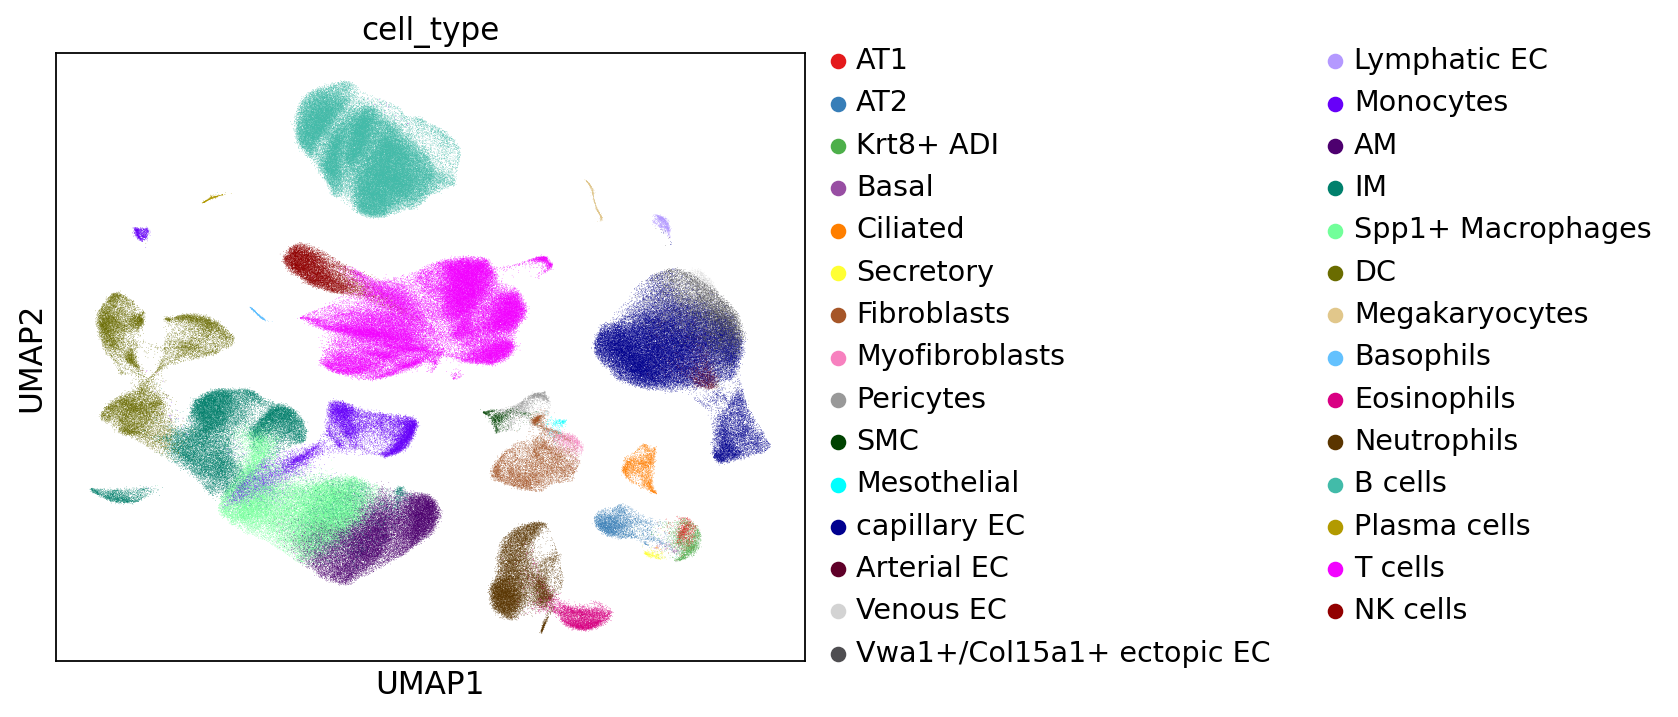

In [13]:
## reorder treatment labels
adata.obs['cell_type'] = adata.obs['cell_type'].astype('category')
adata.obs['cell_type'] = adata.obs['cell_type'].cat.reorder_categories(['AT1',
                                                                        'AT2',
                                                                        'Krt8+ ADI',
                                                                        'Basal',
                                                                        'Ciliated',
                                                                        'Secretory',
                                                                        
                                                                        'Fibroblasts',
                                                                        'Myofibroblasts',
                                                                        'Pericytes',
                                                                        'SMC',
                                                                        'Mesothelial',
                                                                        
                                                                        'capillary EC',
                                                                        'Arterial EC',
                                                                        'Venous EC',
                                                                        'Vwa1+/Col15a1+ ectopic EC',
                                                                        'Lymphatic EC',
                                                                        
                                                                        'Monocytes',
                                                                        'AM',
                                                                        'IM',
                                                                        'Spp1+ Macrophages',
                                                                        'DC',
                                                                        
                                                                        'Megakaryocytes',
                                                                        
                                                                        'Basophils',
                                                                        'Eosinophils',
                                                                        'Neutrophils',
                                                                        
                                                                        'B cells',
                                                                        'Plasma cells',
                                                                        'T cells',
                                                                        'NK cells'
                                                                        ])
sc.pl.umap(adata, color = 'cell_type')

In [14]:
## subset adata to cat relevant for baseline assessment
adata = adata[adata.obs['treatment'].isin(['PBS','Bleo'])].copy()

### Assess cell type specificity

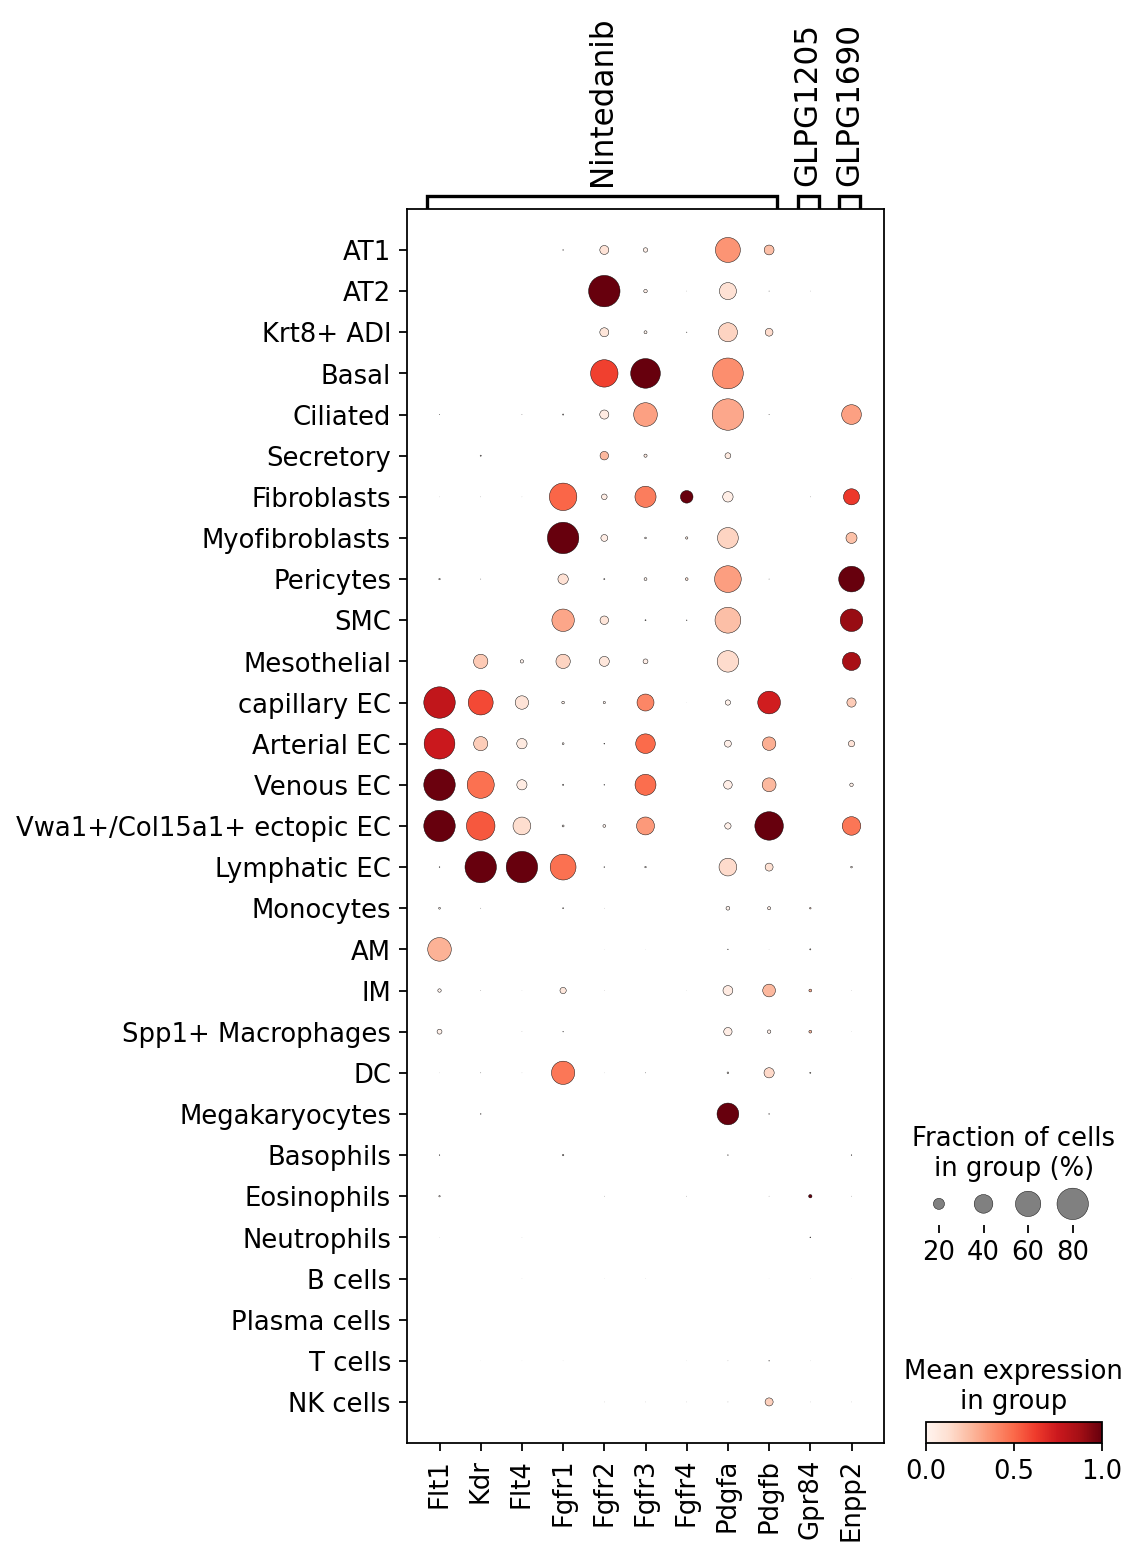

In [15]:
sc.pl.dotplot(adata,
              var_names = target_dict, 
              groupby = 'cell_type',
              standard_scale = 'var',
              dot_max = 0.8,
              cmap = 'Reds',
              save = 'mouse_cell_type_specificity.pdf')

In [16]:
## check some pro-fibrotic cytokines
mouse_profibrotic_genes = [
    "Tgfb1",  # Transforming Growth Factor Beta 1
    "Pdgfa",  # Platelet-Derived Growth Factor A
    "Ctgf",   # Connective Tissue Growth Factor
    "Il6",    # Interleukin 6
    "Il13",   # Interleukin 13
    "Il4",    # Interleukin 4
    "Tnf",    # Tumor Necrosis Factor Alpha
    "Ccl2",   # Chemokine (C-C motif) ligand 2 / MCP-1
    "Il1b",   # Interleukin 1 Beta
    "Fgf2",   # Fibroblast Growth Factor 2
    "Vegfa",  # Vascular Endothelial Growth Factor A
    "Il17a",  # Interleukin 17A
    "Ccl2",   # Chemokine (C-C motif) ligand 2
    "Il10",   # Interleukin 10
    "Edn1",   # Endothelin-1
    "Il11",   # Interleukin 11
    "Mmp9",   # Matrix Metalloproteinase-9
    "Csf2",   # Colony Stimulating Factor 2 (GM-CSF)
    "Cxcl1",  # Chemokine (C-X-C motif) ligand 1 / IL-8 analogue in mice
    "Igf1",   # Insulin-like Growth Factor 1
    "Spp1",   # Secreted Phosphoprotein 1 (Osteopontin)
    "Lpar1",  # Lysophosphatidic Acid Receptor 1
    "Osm",    # Oncostatin M
    "Il33",   # Interleukin 33
    "Il22",   # Interleukin 22
    "Ifng",   # Interferon Gamma
    "Hgf",    # Hepatocyte Growth Factor
    "Egfr",   # Epidermal Growth Factor Receptor
    "Il5",    # Interleukin 5
    "Tslp",    # Thymic Stromal Lymphopoietin
    'Il33'
]

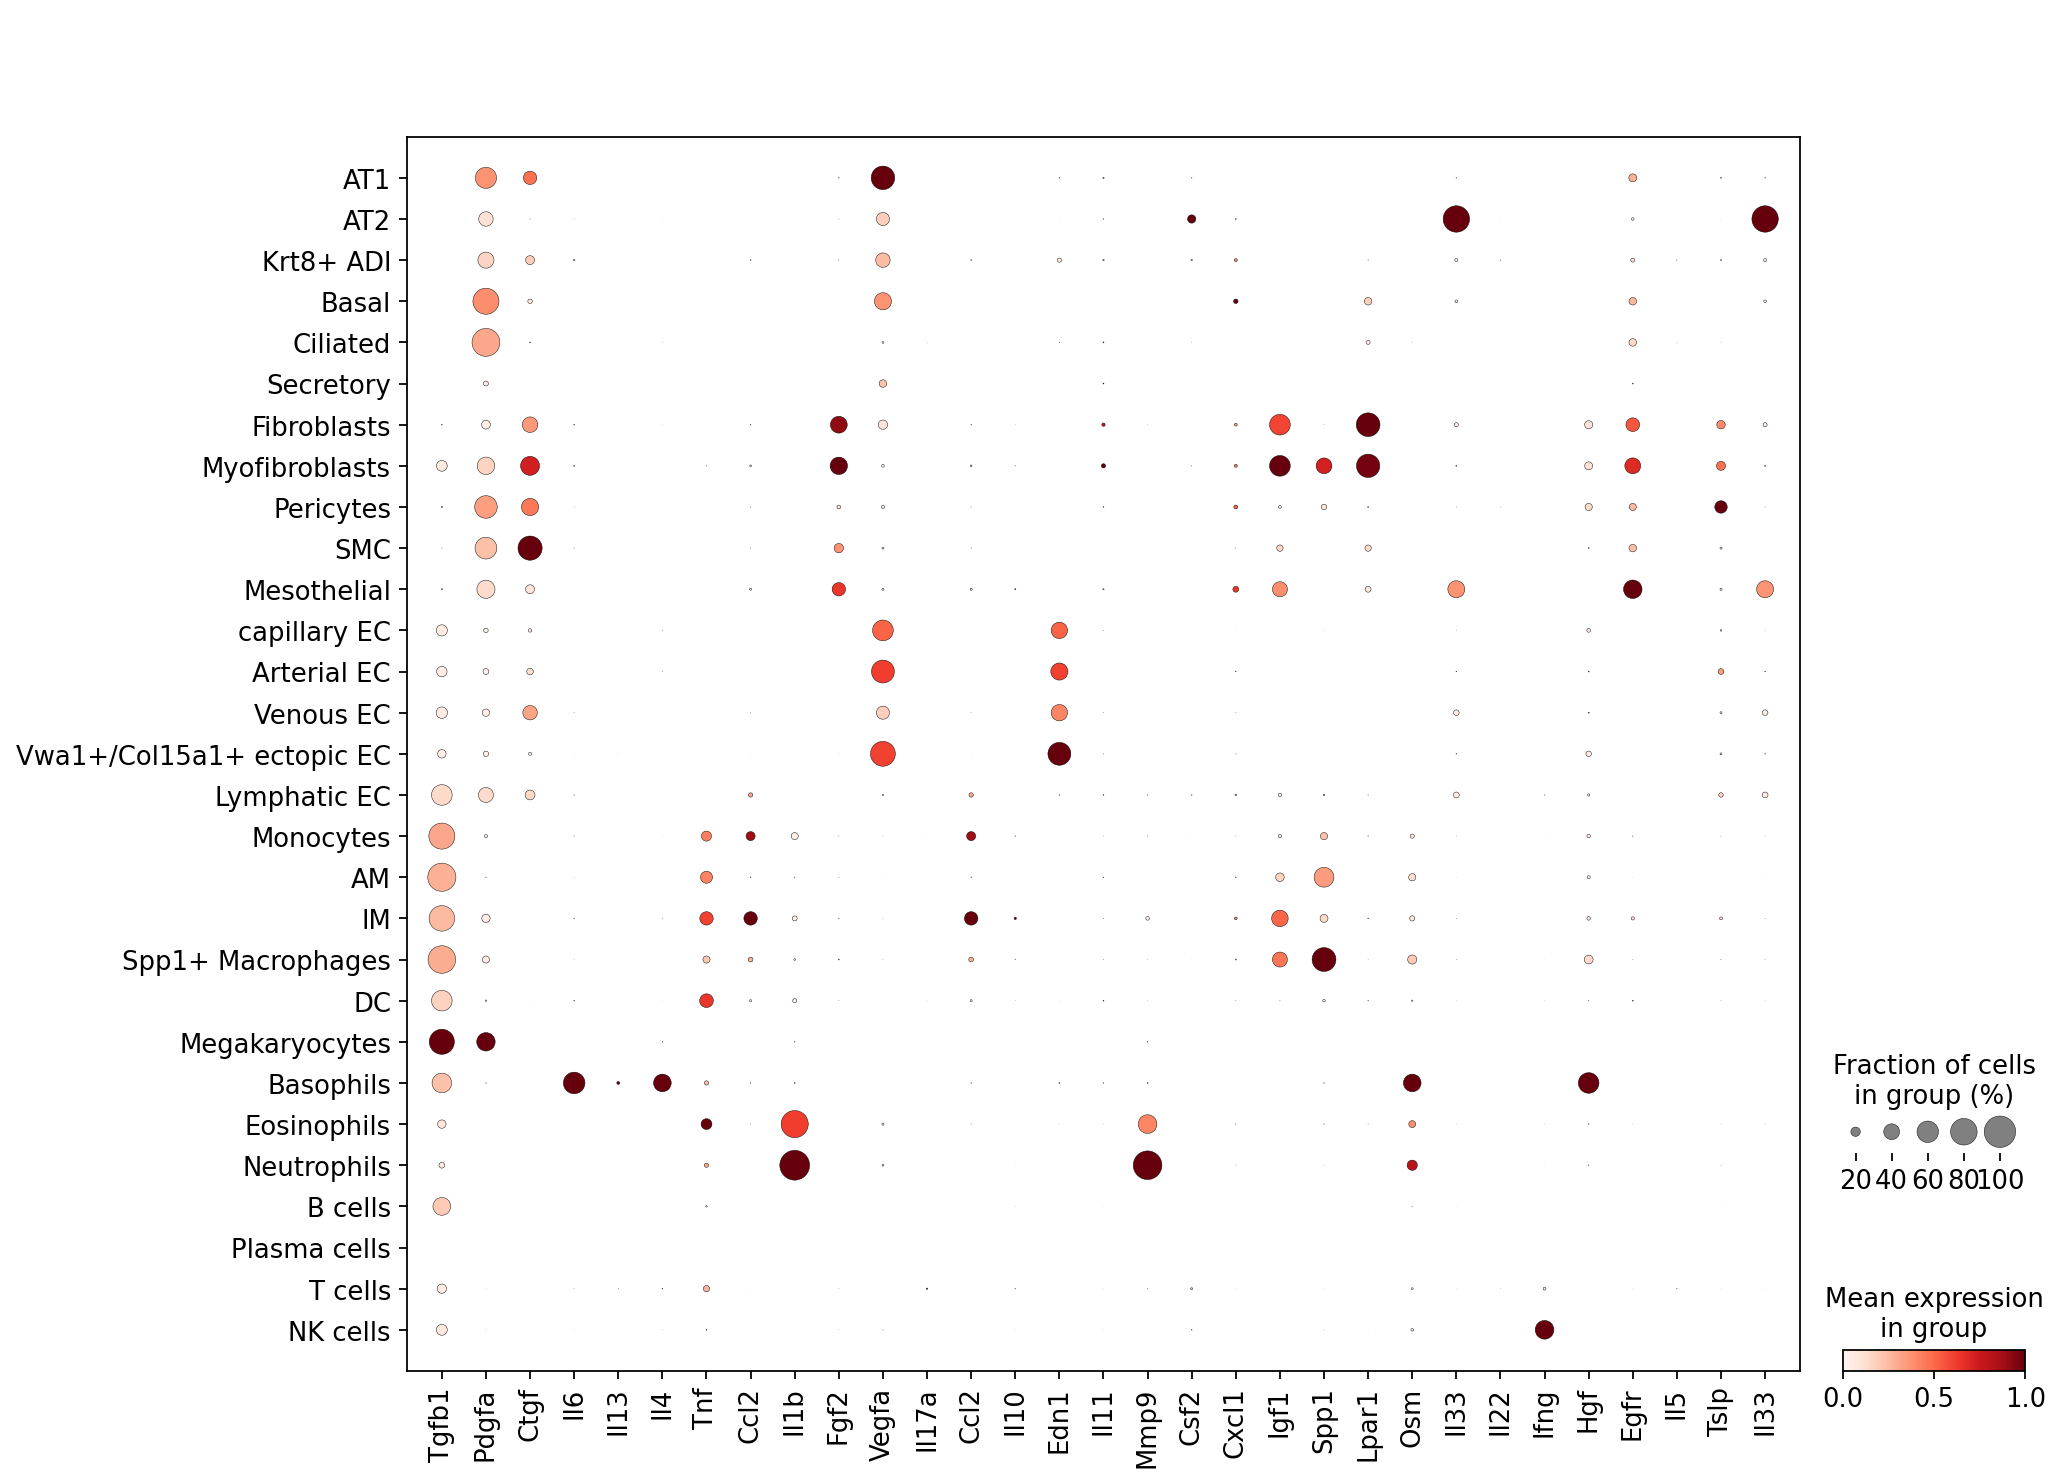

In [17]:
sc.pl.dotplot(adata,
              var_names = mouse_profibrotic_genes, 
              groupby = 'cell_type',
              standard_scale = 'var',
              cmap = 'Reds')

### Assess disease specificity

In [18]:
## calculate log2FC for all genes
sc.tl.rank_genes_groups(adata, 
                        groupby = 'treatment',
                        mask_var = target_list,
                        method = 'wilcoxon')

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:03:02)


In [19]:
## calculate log2FC for all genes
sc.tl.rank_genes_groups(adata, 
                        groupby ='treatment',
                        mask_var = target_list,
                        method = 'wilcoxon')

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:03:03)


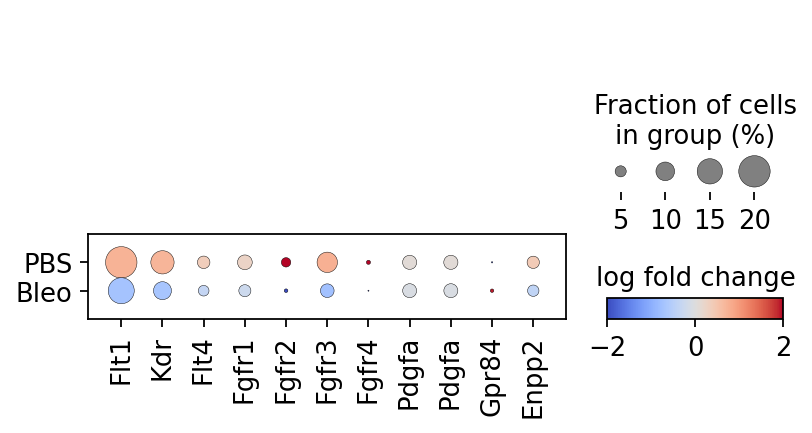

In [20]:
sc.pl.rank_genes_groups_dotplot(adata,
                                groupby='treatment',
                                var_names = target_list, 
                                values_to_plot='logfoldchanges',
                                dot_max = 0.2,
                                vmax=2,
                                vmin=-2,
                                cmap = 'coolwarm',
                                dendrogram = False,
                                save = 'mouse_disease_specificity.pdf')